# Phase 3a - Ablation A1: number of REFINE rounds

Reproduces the paper's Table 5 ("after ONE_SHOT / after 1st REFINE / after 2nd REFINE") on **MNIST-rotated, K* = 4** at the same full-scale config used in `01_main_experiments.ipynb`.

Sweep $R \in \{0, 1, 2\}$ with $\beta = 0.1$ fixed; 3 seeds {0, 1, 2}; outputs `results/ablation_A1.csv` and `results/figures/ablation_A1.png`.

(Earlier versions of this notebook also included A2 trim-vs-plain-mean and A3 $\lambda$-sensitivity; both have been dropped to fit the compute envelope.)


In [1]:
from __future__ import annotations

import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.datasets import make_mnist_federated
from src.federated import TrainConfig, local_train
from src.models import build_model
from src.metrics import misclustering_error
from src.srfca import SRFCAConfig, l2_pairwise, sr_fca
from src.utils import ensure_dir, get_device, set_seed

RESULTS_DIR = ensure_dir(ROOT / "results")
CACHE_DIR = ensure_dir(RESULTS_DIR / "cache")
FIG_DIR = ensure_dir(RESULTS_DIR / "figures")
DEVICE = get_device()

# Match notebook 01's full-scale paper config.
TRAIN_CFG = TrainConfig(lr=0.01, local_epochs=2, batch_size=64, task="classification")
M_CLIENTS = 100
N_PER_CLIENT = 600
TEST_PER_CLIENT = 200
ROUNDS = 280
BETA = 0.1
T_MIN = 2
SEEDS = [0, 1, 2]
SPLIT = "rotated"
ANGLES_ROTATED = (0, 90, 180, 270)

print("device:", DEVICE)


device: cpu


In [2]:
def compute_lambda(seed: int = 0) -> float:
    """Pairwise-distance-valley heuristic, same rule as notebook 01."""
    set_seed(seed)
    fed = make_mnist_federated(
        split=SPLIT, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
        test_per_client=TEST_PER_CLIENT, seed=seed, angles=ANGLES_ROTATED,
    )
    model = build_model(fed).to(DEVICE)
    init = model.flatten_weights().cpu()
    flats = [local_train(model, c, TRAIN_CFG, DEVICE, init_flat=init) for c in fed.clients]
    D = l2_pairwise(flats)
    labels = fed.cluster_labels()
    iu, ju = np.triu_indices(len(flats), k=1)
    same = labels[iu] == labels[ju]
    intra = D[iu[same], ju[same]]
    inter = D[iu[~same], ju[~same]]
    return float(0.5 * (np.percentile(intra, 95) + np.percentile(inter, 5)))

LAMBDA = compute_lambda(seed=0)
print(f"lambda for {SPLIT} (K*=4) = {LAMBDA:.3f}")


lambda for rotated (K*=4) = 0.090


In [3]:
def run_srfca(seed: int, R: int) -> dict:
    set_seed(seed)
    fed = make_mnist_federated(
        split=SPLIT, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
        test_per_client=TEST_PER_CLIENT, seed=seed, angles=ANGLES_ROTATED,
    )
    cfg = SRFCAConfig(
        lambda_=LAMBDA, t=T_MIN, beta=BETA, R=R, rounds_per_refine=ROUNDS,
        local_train_cfg=TRAIN_CFG, dist_mode="l2",
    )
    t0 = time.time()
    clustering = sr_fca(fed, cfg, device=DEVICE, verbose=False)
    wall = time.time() - t0

    model = build_model(fed).to(DEVICE)
    accs = []
    for i, c in enumerate(fed.clients):
        k = int(clustering.assignments[i])
        if k < 0 or k not in clustering.cluster_models:
            k = next(iter(clustering.cluster_models))
        model.load_flat_weights(clustering.cluster_models[k].to(DEVICE))
        model.eval()
        with torch.no_grad():
            accs.append(float((model(c.x_test.to(DEVICE)).argmax(-1) == c.y_test.to(DEVICE)).float().mean().item()))
    return {
        "test_acc": float(np.mean(accs)),
        "misclustering": misclustering_error(fed.cluster_labels(), clustering.assignments),
        "k_found": int(clustering.n_clusters()),
        "wall_sec": wall,
    }

def cached(key: str, fn, *args):
    path = CACHE_DIR / f"ablation_{key}.pkl"
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    out = fn(*args)
    with open(path, "wb") as f:
        pickle.dump(out, f)
    return out


## A1 - $R \in \{0, 1, 2\}$ sweep

In [4]:
R_GRID = [0, 1, 2]
rows = []
for R in R_GRID:
    for seed in SEEDS:
        key = f"A1_R{R}_b{BETA}_T{ROUNDS}_s{seed}"
        rec = cached(key, run_srfca, seed, R)
        rec.update({"R": R, "seed": seed})
        rows.append(rec)
        print(f"[A1 R={R} s={seed}] acc={rec['test_acc']:.3f} mis={rec['misclustering']:.3f} K={rec['k_found']} ({rec['wall_sec']/60:.1f} min)")
df_a1 = pd.DataFrame(rows)
df_a1.to_csv(RESULTS_DIR / "ablation_A1.csv", index=False)
df_a1.groupby("R").agg(acc_mean=("test_acc", "mean"), acc_std=("test_acc", "std"), mis_mean=("misclustering", "mean")).round(3)


[A1 R=0 s=0] acc=0.198 mis=0.000 K=4 (0.0 min)
[A1 R=0 s=1] acc=0.230 mis=0.000 K=4 (0.0 min)
[A1 R=0 s=2] acc=0.240 mis=0.000 K=4 (0.0 min)
[A1 R=1 s=0] acc=0.917 mis=0.000 K=4 (13.8 min)
[A1 R=1 s=1] acc=0.916 mis=0.000 K=4 (13.5 min)
[A1 R=1 s=2] acc=0.919 mis=0.000 K=4 (13.7 min)
[A1 R=2 s=0] acc=0.931 mis=0.000 K=4 (27.4 min)
[A1 R=2 s=1] acc=0.930 mis=0.000 K=4 (27.1 min)
[A1 R=2 s=2] acc=0.932 mis=0.000 K=4 (27.0 min)


,acc_mean,acc_std,mis_mean
R,,,
0,0.222,0.022,0.0
1,0.917,0.002,0.0
2,0.931,0.001,0.0


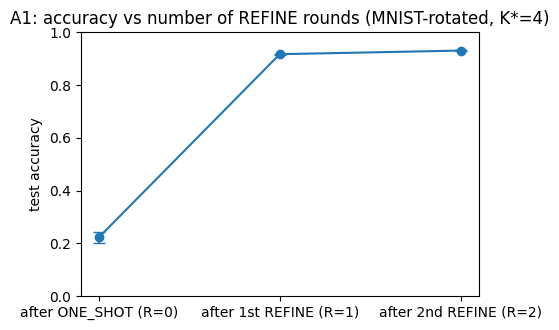

In [5]:
summary = df_a1.groupby("R").agg(acc_mean=("test_acc", "mean"), acc_std=("test_acc", "std")).reset_index()

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.errorbar(summary["R"], summary["acc_mean"], yerr=summary["acc_std"], marker="o", capsize=4, color="C0")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["after ONE_SHOT (R=0)", "after 1st REFINE (R=1)", "after 2nd REFINE (R=2)"])
ax.set_ylabel("test accuracy")
ax.set_title("A1: accuracy vs number of REFINE rounds (MNIST-rotated, K*=4)")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIG_DIR / "ablation_A1.png", dpi=120)
plt.show()
